# How many projects are in Tampa's capital-project map?

A map feature, a project ID, and a project budget are different units of analysis. This notebook asks whether the [City of Tampa capital-project layer](https://arcgis.tampagov.net/arcgis/rest/services/OpenData/CapitalProjects/MapServer/0) has one row per project ID before anyone totals `estcost` or counts projects. It uses the package's checked `capital-projects` entry and retrieves every current feature.

The saved output is a dated observation of a live source. Rerun to refresh it.


## 1. Retrieve the full layer and retain provenance

A complete return means the package checked the returned features against the source object-ID manifest. It does not claim that the publisher's attributes are a transactionally frozen snapshot.


In [1]:
library(tampaBayOpenData)

info <- tbod_dataset_info("capital-projects")
projects <- tbod_get_dataset(
  "capital-projects",
  fields = c("OBJECTID", "projid", "projname", "projtype", "projphase", "estcost"),
  total_timeout = 120
)
source <- tbod_provenance(projects)
stopifnot(isTRUE(source$complete), nrow(projects) == source$returned_rows)
print(data.frame(publisher = source$publisher, retrieved_at = source$retrieved_at,
                 features = nrow(projects), integrity = source$integrity))
print(utils::head(projects[c("OBJECTID", "projid", "projname", "projphase")], 5))


      publisher        retrieved_at features     integrity
1 City of Tampa 2026-10-06 22:39:15      394 full-manifest


# A tibble: 5 x 4
  OBJECTID projid     projname                                         projphase
     <int> <chr>      <chr>                                            <chr>    
1   126620 1000446    Cass St Bridge (#105502) Electrical/Mechanical ~ P2: Desi~
2   126621 1000248    Brorein St Bridge (#105501) Phase 1 Structural ~ P2: Desi~
3   126712 1002445    Twiggs St (Ashley Dr to Nebraska Ave)            P2: Desi~
4   126724 1001618    Greenways, Trail & Gateway Sign - New Tampa Nat~ P2: Desi~
5   126777 TRANS20133 Brorein St Bridge (#105501) Phase 2 Mechanical/~ P2: Desi~


Blank IDs and the literal values `N/A`, `NA`, and `0000000` are flagged as suspected placeholders. We exclude them from the working ID count, but that rule is an exploratory choice rather than a publisher definition. Repeated usable IDs may represent multiple map features, updates, or another source-specific relationship.


In [2]:
project_id <- trimws(as.character(projects$projid))
project_id[is.na(project_id) | project_id == ""] <- NA_character_
suspected_placeholder <- !is.na(project_id) & toupper(project_id) %in%
  c("N/A", "NA", "0000000")
working_id <- project_id
working_id[suspected_placeholder] <- NA_character_
frequency <- table(working_id[!is.na(working_id)])
repeated_ids <- names(frequency)[frequency > 1L]
name_variants <- tapply(as.character(projects$projname), working_id, function(values) {
  values <- trimws(values[!is.na(values)])
  length(unique(values[nzchar(values)]))
})
print(data.frame(
  feature_rows = nrow(projects),
  blank_project_ids = sum(is.na(project_id)),
  suspected_placeholder_rows = sum(suspected_placeholder),
  distinct_working_ids = length(frequency),
  ids_with_multiple_features = length(repeated_ids),
  ids_with_multiple_names = sum(name_variants > 1L, na.rm = TRUE)
))
print(utils::head(sort(table(project_id[!is.na(project_id)]),
                       decreasing = TRUE), 8))


  feature_rows blank_project_ids suspected_placeholder_rows
1          394                14                         15
  distinct_working_ids ids_with_multiple_features ids_with_multiple_names
1                  166                        153                      12



1002588.2   0000000   1002148   1001955   1002401       N/A   1000751   1001541 
       16        10         8         6         6         5         4         4 


## 3. See the effect of repeated IDs

Each bar counts working IDs with that many feature rows. The last bar pools IDs with five or more rows.


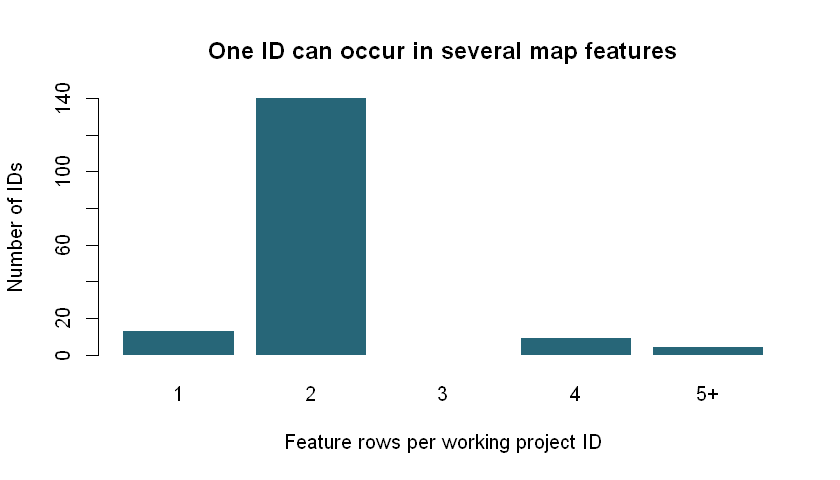

In [3]:
bins <- pmin(as.integer(frequency), 5L)
features_per_id <- table(factor(bins, levels = 1:5,
                                labels = c("1", "2", "3", "4", "5+")))
options(repr.plot.width = 7, repr.plot.height = 4)
barplot(features_per_id, col = "#276678", border = NA,
        xlab = "Feature rows per working project ID", ylab = "Number of IDs",
        main = "One ID can occur in several map features")


## What this means

The table establishes the feature-to-ID relationship in the current layer. It does **not** establish a canonical project count or project-level cost. Summing `estcost` across feature rows would count repeated IDs more than once; selecting one row per ID requires a publisher-supported rule for conflicting names, phases, and costs. The source represents public-facing mapped projects, not the entire City capital ledger.
